# Fashion Mnist ewaluacja

Ten notebook jest przeznaczony do badania algorytmów na zbiorze **Fashion_Mnist**

Zbiór Fashion-Mnist jest standardowym zbiorem w computer vision (Hello World w świece CV) 


In [1]:
import tensorflow_datasets as tfds

## Loading data

In [2]:
import torch

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

transform = transforms.Compose([

    transforms.ToTensor()

])

In [ ]:
from torchvision import datasets

mnist = datasets.MNIST(root="./data", train=True, download=True)
X_full = mnist.data.numpy().reshape(len(mnist), -1).astype("float32") / 255.0
y_full = mnist.targets.numpy()

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.16MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 230kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.42MB/s]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import trustworthiness
from sklearn.metrics import (
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)
from utils.isomap_umap import isomap, umap_reduce

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

rng = np.random.default_rng(1)
idx = rng.choice(len(X_full), size=3000, replace=False)
X, y = X_full[idx], y_full[idx] 

n_clusters = len(np.unique(y))            
neighbor_values = [5, 10, 15, 30, 40, 50]

metric_names = ["Trustworthiness", "NMI", "Silhouette", "Calinski-Harabasz"]
res = {m: {"isomap": [], "umap": []} for m in metric_names}

for k in neighbor_values:

    for name, fn in [("isomap", isomap), ("umap", umap_reduce)]:
        emb = fn(X, n_neighbors=k, scale=False)         
        km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(emb)

        res["Trustworthiness"][name].append(trustworthiness(X, emb))
        res["NMI"][name].append(normalized_mutual_info_score(y, km))
        res["Silhouette"][name].append(silhouette_score(emb, y))
        res["Calinski-Harabasz"][name].append(calinski_harabasz_score(emb, y))
    print(f"n_neighbors={k} gotowe")


n_neighbors=5 gotowe
n_neighbors=10 gotowe
n_neighbors=15 gotowe
n_neighbors=30 gotowe
n_neighbors=40 gotowe
n_neighbors=50 gotowe


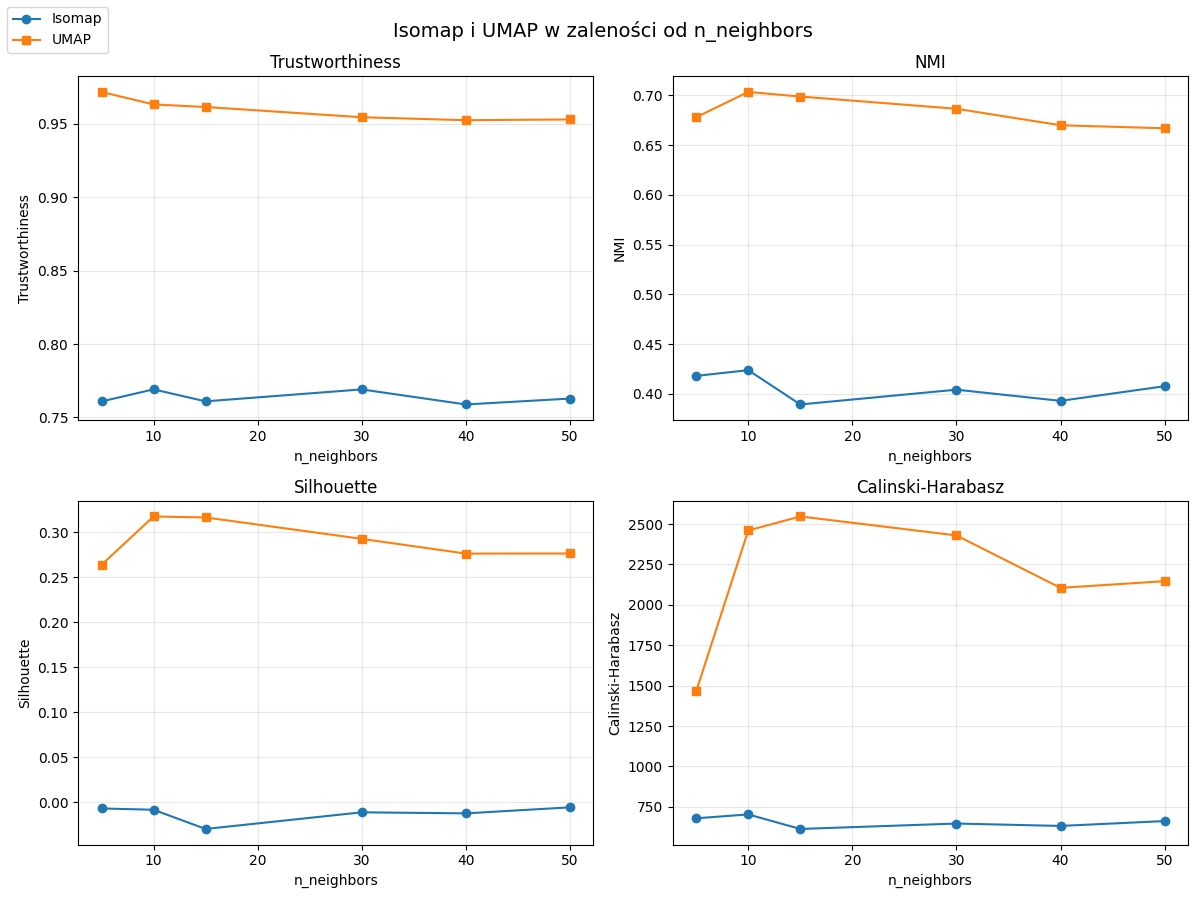

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, metric in zip(axes.ravel(), metric_names):
    ax.plot(neighbor_values, res[metric]["isomap"], "o-", label="Isomap")
    ax.plot(neighbor_values, res[metric]["umap"], "s-", label="UMAP")
    ax.set_title(metric)
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=1)
fig.suptitle("Isomap i UMAP w zaleności od n_neighbors",

             fontsize=14)
fig.tight_layout()
plt.show()